# Winter - CMIP6 models

## Script to process multiple years using a Fourier Series Fit to the Temp Time Series, generate diagnostic plots, and some maps

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import warnings
warnings.filterwarnings('ignore')



In [2]:
###################
# helper functions
###################
def WinterStatsFourier(temp_data, temp_data_next, threshold, save_plot, calc_tmax, calc_cold):
    '''

    Function that uses the input 25th percentile temperature in K to identify the winter from a time series of temperatures.
    Input data should already be set to 365 days.

    Args:
        temp_data: xarray of temperature data for a single grid cell for the year of interest
        temp_data_next: xarray of temperature data for a single grid cell for the following year (for NH winters)
        threshold: xarray for the 25th percentile threshold to use
        save_plot: save out a png of the time series with threshold, day of max, winter start/end shown
        calc_tmax: should the day of max temp during winter be calculated (slows processing)
        calc_cold: should the accumulated cold during winter be calculated (slows processing), includes mean temp
        
    Returns:
        start day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed below threshold (25th percentile)
        end day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed above threshold (25th percentile) 
        day with max temp: during the winter period, the day that had the highest mean daily t2m 
        accumulated cold in winter: sum of degree days below threshold during winter, 0 if none
        winter length: number of days the smoothed fit to the t2m data is below threshold, 0 if none
        winterlike days: number of days in the 12 month period that had a mean T2m <= the threshold
        rmse: root mean squared error of Fourier fit to temperature time series
        mean temp: the mean temperature in K for the winter period, 0 if there was no time below threshold
        
    Example:
        start_day, last_day, day_of_max, acc_cold, winter_length, winterlike_days, rmse, mean_temp = WinterStats(temps, temps_next, thresh, True, False, True)

    '''

    # default values
    first_day = 0 
    last_day = 0
    tmax_day = 0 
    winter_cold = 0 
    winter_length = 0
    winter_like_days = 0
    rmse = 0.0
    mean_t = 0

    # split method based on NH or SH

    ######
    # Southern Hemisphere (uses current year only)
    if temp_data.lat.values < 0:
        # extract DOY and T2m values for those days
        x1 = temp_data.time.dt.dayofyear.values
        y1 = temp_data.values

        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020 and Scott et al 2026
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
    
        # create some x values for plotting  fit
        x_values = np.linspace(min(x1), max(x1), 365) 
    
        # use fit to get stats
        # in Scott et al 2026 summer was >= threshold so using same definition for (winter <= threshold)
        winter_length = np.count_nonzero(y_lp <= threshold.values)
        winter_days = np.where(y_lp <= threshold.values)[0]

        # count of winter-like days in the year (any time during the year)
        winter_like_days = np.where(y1 <= threshold.values)[0].size

        # deal with those that didn't have any days below threshold
        if winter_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't below threshold but still want the value so can be any day of the year
                tmax_day = int(temp_data.argmax() + 1)
            if calc_cold:
                # determine accumulated cold over winter as sum of degree days below threshold
                # in this case there are none
                winter_cold = 0
        else:
            # otherwise can get start/end days 
            first_day = int(x_values[min(winter_days)])
            #OLD:# last_day = int(x_values[max(summer_days)])

            # end day comes after first day so find next crossing of  fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[first_day:365]) > threshold.values)

            # if it does cross back above threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back above threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # winter length is the span between first and last + 1 to include the end day
            winter_length = last_day - first_day + 1    
            
            if calc_tmax:
                # day with max temp that is in winter period
                if first_day == last_day: #only one day of winter
                    tmax_day = first_day
                else:
                    # if winter_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (temp_data[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((temp_data[(first_day):(last_day+1)].argmax() + 1) + first_day)        
            if calc_cold:
                # determine accumulated cold over winter as sum of degree (days) below threshold to daily mean temp
                # also save mean temp
                sh_winter = temp_data[(first_day):(last_day+1)]

                # area above zero for days below threshold line to be subtracted
                below_thresh_area = float(sh_winter.where(sh_winter.values <= threshold.values).sum())

                # number of days where mean temp was below threshold
                days_below_thresh = sh_winter.where(sh_winter.values <= threshold.values).count()
                
                # calculate difference to get only the area between threshold and data (daily mean temp on winter days)
                winter_cold = (threshold.values * days_below_thresh) - below_thresh_area

                # if there is a winter we can get the mean temp for the whole winter
                if len(sh_winter) > 0:
                    mean_t = sh_winter.values.mean()
                    # mean_hs = float(above_thresh/days_above_thresh) - threshold.values

                
    
    ######
    # Northern Hemisphere (uses current year and following year)
    else: 
        # concat both years
        ds_two = xr.concat([temp_data, temp_data_next], dim="time")

        # get the current year for slicing
        input_year = temp_data.time.dt.year.values[0]

        # select July 1 - June 30 across the two years to do fit
        startdate = str(input_year)+'-07-01' # 182nd day of a normal year
        enddate = str(input_year+1)+'-06-30'
        nh_yr = ds_two.sel(time=slice(startdate,enddate))
        
        # DOY (relative to July 1) and T2m values for those days
        x1 = np.arange(1,len(nh_yr.time)+1) 
        y1 = nh_yr.values
        
        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020 and Scott et al 2026
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
        
        # create some x values for plotting  fit
        x_values = np.linspace(min(x1), max(x1), 365) 
        winter_length = np.count_nonzero(y_lp <= threshold.values)
        winter_days = np.where(y_lp <=  threshold.values)[0]

        # count of winter-like days in the year (any time during the year)
        winter_like_days = np.where(y1 <= threshold.values)[0].size

        # check if summer length is 0
        if winter_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(nh_yr.argmax() + 1)
            if calc_cold:
                # determine accumulated heat over winter as sum of degree days below threshold
                # in this case there are none
                winter_cold = 0
        else:
            # otherwise can get start/end days but note these are relative to July 1
            first_day = int(x_values[min(winter_days)])

            # end day comes after first day so find next crossing of  fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[first_day:365]) > threshold.values)

            # if it does cross back above threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back above threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # summer length is the span between first and last + 1 to include the end day
            winter_length = last_day - first_day + 1           
    
            
            if calc_tmax:
                # day with max temp that is in winter period
                if first_day == last_day: #only one day of winter
                    tmax_day = first_day
                else:
                    # if winter_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (nh_yr[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((nh_yr[(first_day):(last_day+1)].argmax() + 1) + first_day)  
            if calc_cold:
                # determine accumulated cold over winter as sum of degree (days) below threshold to daily mean temp
                # also save the mean temp of winter
                nh_winter = nh_yr[(first_day):(last_day+1)]

                # area above zero for days below threshold line to be subtracted
                below_thresh_area = float(nh_winter.where(nh_winter.values <= threshold.values).sum())

                # number of days where mean temp was below threshold
                days_below_thresh = nh_winter.where(nh_winter.values <= threshold.values).count()
                
                # calculate difference to get only the area between threshold and data (daily mean temp on winter days)
                winter_cold = (threshold.values * days_below_thresh) - below_thresh_area
    
                # if there is a winter we can get the mean temp for the whole winter
                if len(nh_winter) > 0:
                    mean_t = nh_winter.values.mean()
                
                

                
    # make and save plot if desired
    ##
    ##
    if save_plot:
        cell_lat = temp_data.lat.values
        cell_lon = temp_data.lon.values
        yr = temp_data.time.dt.year.values[0]

        plt.figure(figsize=(16,6))
        plt.plot(x1,y1, label='daily mean T2m')
        plt.plot(x_values, y_lp, label='Fourier fit 1-4th Harmonic', color='red')
        plt.axhline(threshold.values, color="black", linewidth=0.8, linestyle="dashed") 
        plt.axvline(first_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(last_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.annotate('start', xy=(first_day-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('end', xy=(last_day-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('winter = '+str(winter_length)+' days', xy=(first_day+5,np.mean(y_lp)), fontsize=18)
        plt.annotate('25th percentile = '+str(np.round(threshold.values,1))+'K', xy=(0,threshold.values+1), fontsize=18)
        plt.annotate('RMSE = '+str(np.round(rmse,2)), xy=(0, np.min(y1)), fontsize=18)
        plt.annotate('Mean = '+str(np.round(mean_t,2))+'K', xy=(last_day-5, mean_t-1), fontsize=12)

        if calc_tmax:
            # add annotation for tmax_day
            plt.annotate('Tmax day '+str(tmax_day), xy=(tmax_day,np.max(y1)), fontsize=12)

        if cell_lat > 0:
            # NH days are relative to July 1
            plt.xlabel('DOY (' + str(yr) + ') relative to July 1')
        else:
            plt.xlabel('DOY (' + str(yr) + ')')
        plt.ylabel('Mean Daily Temp (K)')
        plt.title(str(yr) + " Winter for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
        plt.legend()
        plt.savefig("fourierfit_stats_"+str(cell_lat)+"_"+str(cell_lon)+"_"+str(yr)+"_winter.png")
        plt.show()
    
    # return
    return int(first_day), int(last_day), int(tmax_day), float(winter_cold), int(winter_length), int(winter_like_days), float(rmse), float(mean_t)


# a function that takes in a dataset of global t2m values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a t2m value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.t2m[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.t2m[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap', use_cftime=None)

        # ensure time is datetime64
        output_ds["time"] = output_ds.time.dt.strftime('%Y-%m-%d')
        output_ds['time'] = pd.to_datetime(output_ds['time'])

        # return the new dataset 
        return output_ds
    else:
        return input_ds
    

## GFDL-ESM4

#### Load baseline 25% percentile values from GFDL-ESM4 historical data per grid cell
- prior use of ERA5 baseline showed bias especially for CanESM data

In [4]:
# get baseline
file_path = '../../../../Data/CMIP6/GFDL-ESM4/FixedCoords/baseline/computed_1961-1990-full_25th.nc'
c_25_gfdl = xr.open_dataarray(file_path)
c_25_gfdl.values


array([[213.42943573, 213.46327209, 213.50029373, ..., 213.32437515,
        213.36006927, 213.39424896],
       [216.06673431, 216.19672775, 216.31978226, ..., 215.72757339,
        215.83605957, 215.95020294],
       [220.52465439, 220.78456879, 221.02615738, ..., 219.82786179,
        220.05454254, 220.28092957],
       ...,
       [241.62268829, 241.62092972, 241.59852982, ..., 241.68361664,
        241.65729904, 241.64398575],
       [241.68133545, 241.68395615, 241.66807938, ..., 241.67079163,
        241.67661285, 241.68196106],
       [241.76016235, 241.7466507 , 241.74739075, ..., 241.76098633,
        241.75382233, 241.75619888]], shape=(180, 288))

### Load GFDL-ESM4 data

In [5]:
file_path = '../../../../Data/CMIP6/GFDL-ESM4/FixedCoords/*.nc'
#file_path = '../../../Data/CMIP6/GFDL-ESM4/tas_day_GFDL-ESM4_ssp245_r1i1p1f1_gr1_20150101-20241231.nc'

ds_gfdl = xr.open_mfdataset(file_path)

In [6]:
ds_gfdl

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 12775, lat: 180, bnds: 2, lon: 288)
Coordinates:
  * time       (time) datetime64[ns] 102kB 1990-01-01T12:00:00 ... 2024-12-31...
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * bnds       (bnds) float64 16B 1.0 2.0
  * lon        (lon) float64 2kB -179.4 -178.1 -176.9 ... 176.9 178.1 179.4
    height     float64 8B 2.0
Data variables:
    lat_bnds   (time, lat, bnds) float64 37MB dask.array<chunksize=(1825, 180, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 59MB dask.array<chunksize=(1825, 288, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    time_bnds  (time, bnds) object 204kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               day
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/ef0a0372-2d5b-4290-89a9-83c849cfa64e
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

### Test for Vancouver 2000 - nearest grid cell

In [7]:
#test for Vancouver
input_lat = 49.246
input_lon = -123.116

thresh = c_25_gfdl.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh

<xarray.DataArray 'tas' ()> Size: 8B
array(274.723129)
Coordinates:
    lat       float64 8B 49.5
    lon       float64 8B -123.1
    quantile  float64 8B ...
Attributes:
    long_name:  25th percentile 2m Temperature for the data across available ...
    units:      K

In [8]:
input_year = 2000

ds = ds_gfdl.sel(time = str(input_year))
curr = ds.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
dsnext = ds_gfdl.sel(time = str(input_year+1))
nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
curr, nxt

(<xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2000-01-01T12:00:00 ... 2000-12-31T12:...
     height   float64 8B 2.0
     lat      float64 8B 49.5
     lon      float64 8B -123.1
 Attributes:
     long_name:      Near-Surface Air Temperature
     units:          K
     cell_methods:   area: time: mean
     cell_measures:  area: areacella
     standard_name:  air_temperature
     interp_method:  conserve_order2
     original_name:  tas,
 <xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2001-01-01T12:00:00 ... 2001-12-31T12:...
     height   float64 8B 2.0
     lat      float64 8B 49.5
     lon      float64 8B -123.1
 Attributes:
     long_name:      Near-Surface Air Temperature
     units:          K
 

#### Vancouver 2000 winter testing

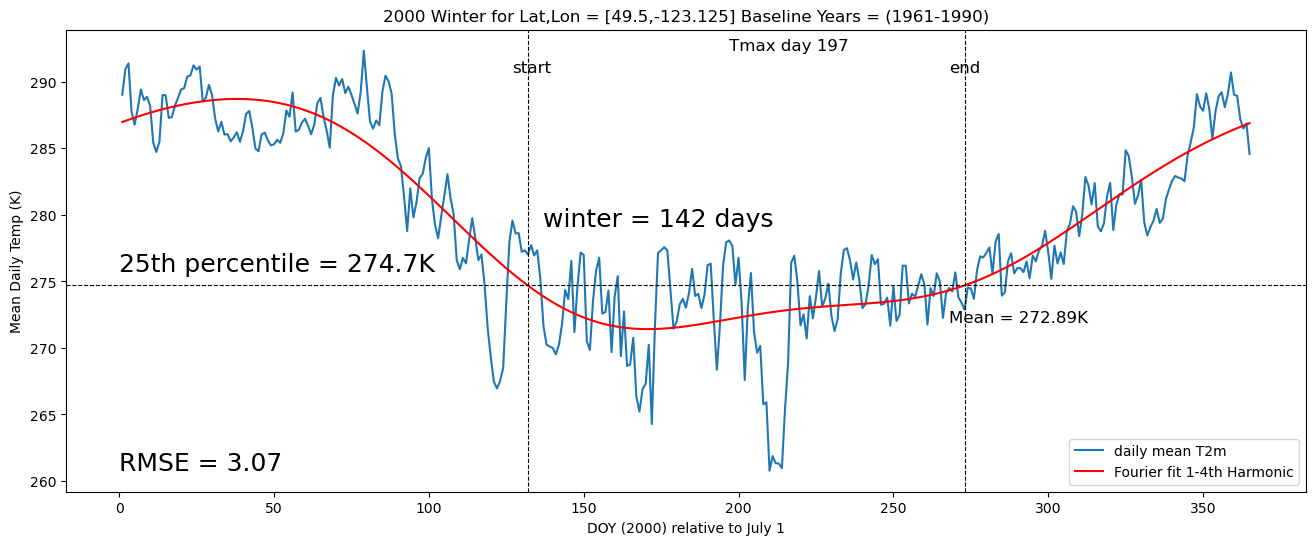

(132,
 273,
 197,
 334.93798828125,
 142,
 108,
 3.066535472869873,
 272.8936462402344)

In [9]:
start_day, last_day, day_of_max, acc_cold, winter_length, winterlike_days, rmse, mean_temp = WinterStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_cold, winter_length, winterlike_days, rmse, mean_temp

#### test a few other years

In [10]:
%%time
input_year = 2021

ds = ds_gfdl.sel(time = str(input_year))
curr = ds.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
dsnext = ds_gfdl.sel(time = str(input_year+1))
nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
curr, nxt

CPU times: user 17.6 ms, sys: 1.17 ms, total: 18.7 ms
Wall time: 18.2 ms


(<xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2021-01-01T12:00:00 ... 2021-12-31T12:...
     height   float64 8B 2.0
     lat      float64 8B 49.5
     lon      float64 8B -123.1
 Attributes:
     long_name:      Near-Surface Air Temperature
     units:          K
     cell_methods:   area: time: mean
     cell_measures:  area: areacella
     standard_name:  air_temperature
     interp_method:  conserve_order2
     original_name:  tas,
 <xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2022-01-01T12:00:00 ... 2022-12-31T12:...
     height   float64 8B 2.0
     lat      float64 8B 49.5
     lon      float64 8B -123.1
 Attributes:
     long_name:      Near-Surface Air Temperature
     units:          K
 

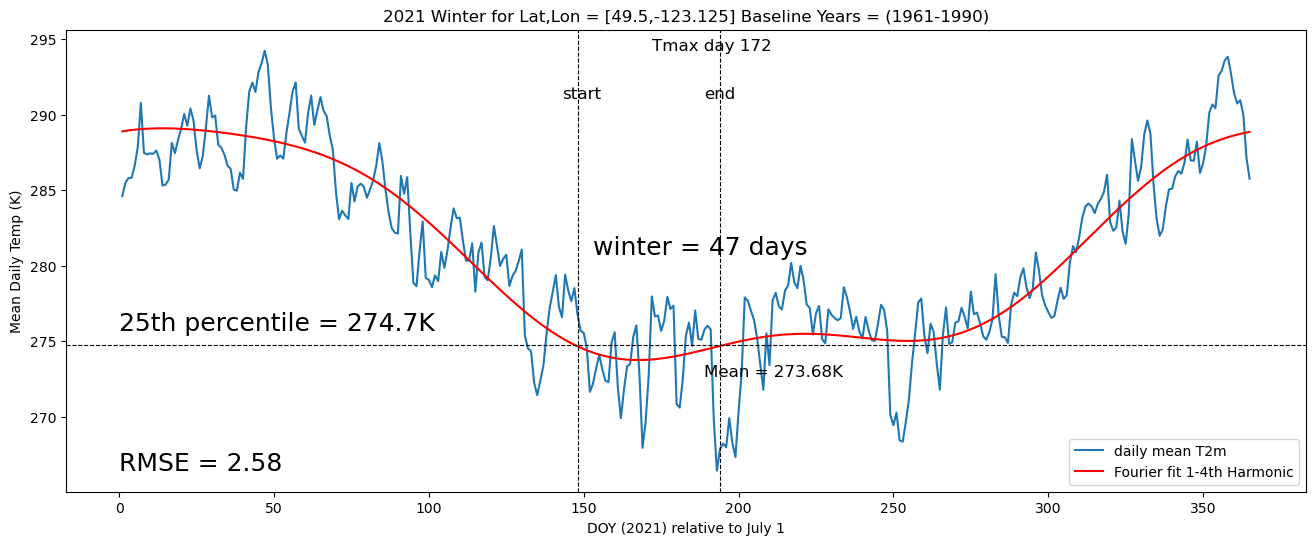

(148,
 194,
 172,
 80.18907165527344,
 47,
 51,
 2.5778539180755615,
 273.6802978515625)

In [11]:
start_day, last_day, day_of_max, acc_cold, winter_length, winterlike_days, rmse, mean_temp = WinterStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_cold, winter_length, winterlike_days, rmse, mean_temp

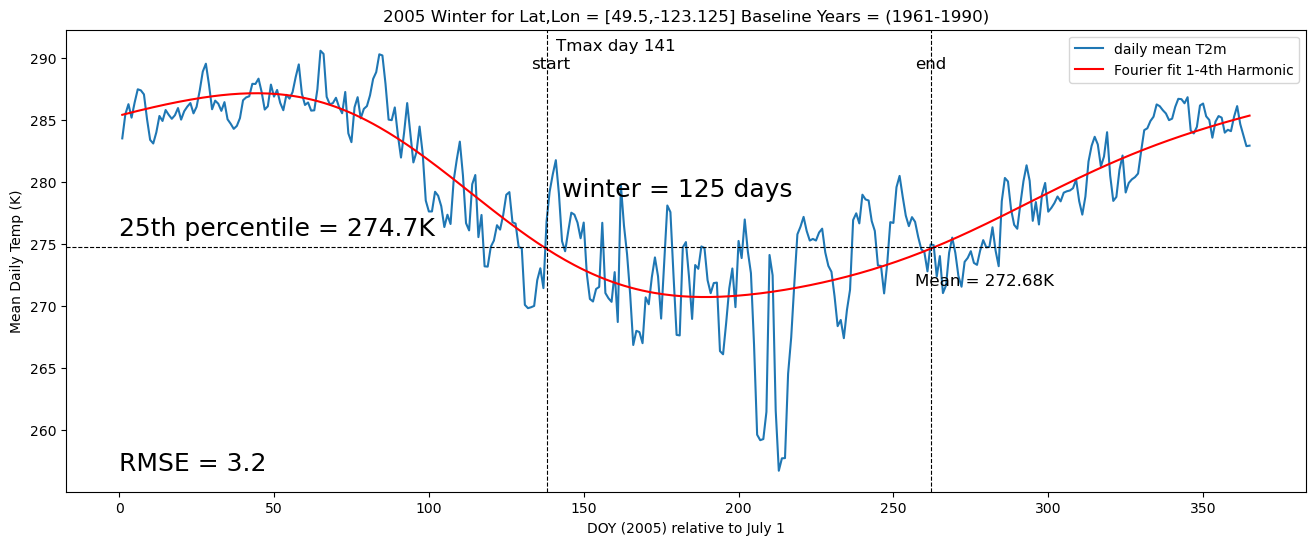

CPU times: user 1.32 s, sys: 132 ms, total: 1.45 s
Wall time: 1.29 s


(138,
 262,
 141,
 369.5061798095703,
 125,
 101,
 3.1960835456848145,
 272.68115234375)

In [15]:
%%time
input_year = 2005

ds = ds_gfdl.sel(time = str(input_year))
curr = ds.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
dsnext = ds_gfdl.sel(time = str(input_year+1))
nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon, method="nearest")

start_day, last_day, day_of_max, acc_cold, winter_length, winterlike_days, rmse, mean_temp = WinterStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_cold, winter_length, winterlike_days, rmse, mean_temp

### Try Sydney Australia to test SH functioning

In [17]:
input_lat = -33 - 52/60 - 4/3600
input_lon = 151.25
thresh = c_25_gfdl.sel(lat=input_lat, lon=input_lon, method="nearest")

curr = ds.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
curr, nxt

(<xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2005-01-01T12:00:00 ... 2005-12-31T12:...
     height   float64 8B 2.0
     lat      float64 8B -33.5
     lon      float64 8B 151.9
 Attributes:
     long_name:      Near-Surface Air Temperature
     units:          K
     cell_methods:   area: time: mean
     cell_measures:  area: areacella
     standard_name:  air_temperature
     interp_method:  conserve_order2
     original_name:  tas,
 <xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2006-01-01T12:00:00 ... 2006-12-31T12:...
     height   float64 8B 2.0
     lat      float64 8B -33.5
     lon      float64 8B 151.9
 Attributes:
     long_name:      Near-Surface Air Temperature
     units:          K
 

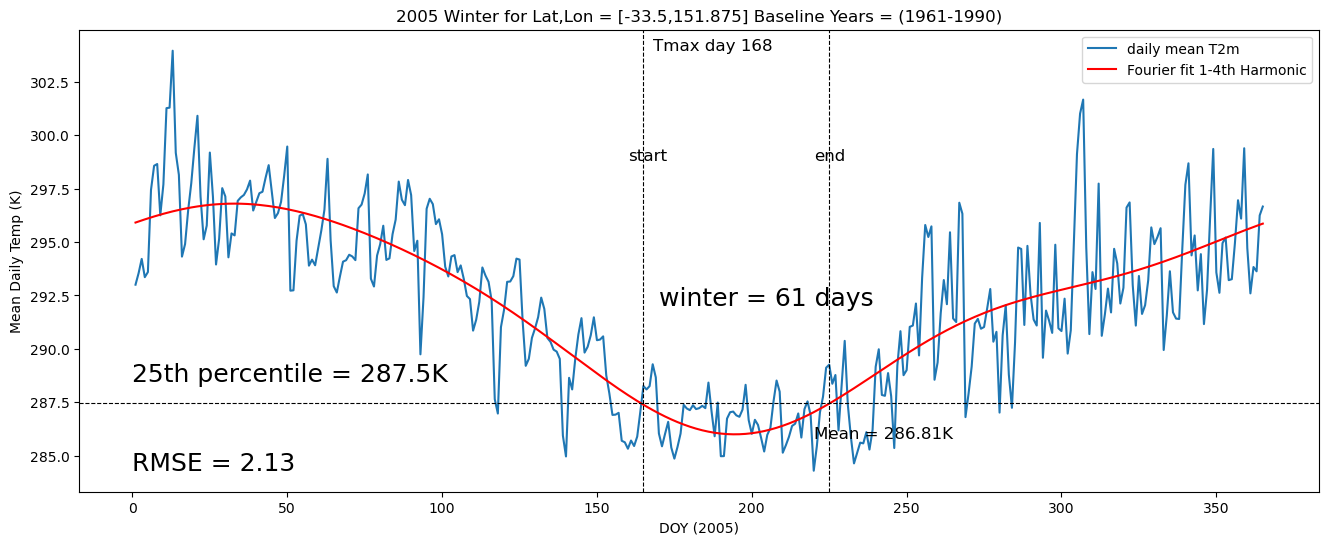

(165,
 225,
 168,
 52.832000732421875,
 61,
 73,
 2.1349129676818848,
 286.8073425292969)

In [18]:
# test for Sydney
start_day, last_day, day_of_max, acc_cold, winter_length, winterlike_days, rmse, mean_temp = WinterStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_cold, winter_length, winterlike_days, rmse, mean_temp

### Main Loop: loop through multiple years to generate Winter stats

In [20]:
# grid parameters for looping
num_lat = ds_gfdl.lat.shape[0]
num_lon = ds_gfdl.lon.shape[0]

loop_lats = ds_gfdl.lat.values[:num_lat]
loop_lons = ds_gfdl.lon.values[:num_lon]
#loop_lats, loop_lons

In [32]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1991, 2000,1)

process_yrs

array([1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999])

In [33]:
%%time

# Runtime: 1.7 min for 1 year
# XX for 25 years

# loop thru the years in the defined array above
for input_year in process_yrs:
    # timer
    start = dt.now()

    ds = ds_gfdl.sel(time = str(input_year))

    dsnext = ds_gfdl.sel(time = str(input_year+1))

    # load into memory to speed up the summer stats processing
    ds.load()
    dsnext.load()

    # empty data arrays for winter stats
    winterlength = xr.DataArray(np.zeros((num_lat,num_lon)), 
                                coords=[loop_lats, loop_lons], 
                                dims=['lat','lon'])
    winterstart = xr.DataArray(np.zeros((num_lat,num_lon)), 
                               coords=[loop_lats, loop_lons], 
                               dims=['lat','lon'])
    winterend = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    wintermax = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    wintercold = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    winterrmse = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    wintermean = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    winterlikedays = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    
    # add attributes
    winterstart.attrs["long_name"] = "Start day of winter for the year (DOY in [1,365])"
    winterstart.attrs["units"] = "Day of year"
    
    winterend.attrs["long_name"] = "Last day of winter for the year (DOY in [1,365])"
    winterend.attrs["units"] = "Day of year"
    
    winterlength.attrs["long_name"] = "Duration of winter for the year"
    winterlength.attrs["units"] = "Days"
    
    wintermax.attrs["long_name"] = "Day of max mean temp during winter for the year"
    wintermax.attrs["units"] = "Day of year"
    
    wintercold.attrs["long_name"] = "Accumulated cold during winter for the year"
    wintercold.attrs["units"] = "Degree-Days"
    
    winterrmse.attrs["long_name"] = "Root mean squared error of Fourier fit"
    winterrmse.attrs["units"] = "Degrees [K]"

    wintermean.attrs["long_name"] = "Mean temperature during the winter period"
    wintermean.attrs["units"] = "Degrees [K]"

    winterlikedays.attrs["long_name"] = "Number of days in the 12-month period with mean T2m at or below threshold"
    winterlikedays.attrs["units"] = "Days"
    

    # loop through all of the lat,lon of interest
    for input_lat in loop_lats:
        for input_lon in loop_lons:
            # get threshold from c_25 - using closest location since not same grid as GFDL-ESM4
            thresh = c_25_gfdl.sel(lat=input_lat,lon=input_lon, method='nearest')
    
            # all the temps for that grid cell over time for this year and next (for NH)
            curr = ds.tas.sel(lat=input_lat,lon=input_lon) 
            nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon)
    
            # build winter stats for the grid cell and produce the plot if desired (currently False)
            start_day, last_day, day_of_max, acc_cold, winter_length, winterlike_days, rmse, mean_temp = WinterStatsFourier(curr, nxt, thresh, False, True, True)
            
            # xarray requires strange indexing in order to replace values by coordinate
            winterstart.loc[input_lat, input_lon] = start_day
            winterend.loc[input_lat, input_lon] = last_day
            wintermax.loc[input_lat, input_lon] = day_of_max
            wintercold.loc[input_lat, input_lon] = acc_cold
            winterlength.loc[input_lat, input_lon] = winter_length
            winterrmse.loc[input_lat, input_lon] = rmse
            wintermean.loc[input_lat, input_lon] = mean_temp
            winterlikedays.loc[input_lat, input_lon] = winterlike_days

    # save it out
    sum_ds = xr.Dataset(data_vars={'WinterStart':winterstart,
                               'WinterEnd':winterend,
                               'WinterTmax':wintermax,
                               'WinterCold':wintercold,
                               'WinterLength':winterlength,
                                   'WinterlikeDays':winterlikedays,
                               'WinterRMSE':winterrmse,
                                'WinterMeanT':wintermean})
    output_path = '../../../../Data/CMIP6/GFDL-ESM4/Winters/'+str(input_year)+'_GFDL-ESM4_r1i1p1f1_winter_stats.nc'
    sum_ds.to_netcdf(output_path)


    end = dt.now()
    elapsed = (end-start).total_seconds()/60.0
    print("Time for "+str(input_year)+" :"+str(elapsed)+" min")

Time for 1991 :1.6823185500000002 min
Time for 1992 :1.7419635666666666 min
Time for 1993 :1.7469847833333332 min
Time for 1994 :1.70715405 min
Time for 1995 :1.7313666166666666 min
Time for 1996 :1.7196299333333334 min
Time for 1997 :1.7152959666666667 min
Time for 1998 :1.6989984833333334 min
Time for 1999 :1.6828417 min
CPU times: user 15min 10s, sys: 11.9 s, total: 15min 22s
Wall time: 15min 25s


### Inspect results

In [34]:
# check it
filepath = '../../../../Data/CMIP6/GFDL-ESM4/Winters/1999_GFDL-ESM4_r1i1p1f1_winter_stats.nc'
test = xr.open_mfdataset(filepath)
test

<xarray.Dataset> Size: 3MB
Dimensions:         (lat: 180, lon: 288)
Coordinates:
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 2kB -179.4 -178.1 -176.9 ... 176.9 178.1 179.4
Data variables:
    WinterStart     (lat, lon) float64 415kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    WinterEnd       (lat, lon) float64 415kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    WinterTmax      (lat, lon) float64 415kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    WinterCold      (lat, lon) float64 415kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    WinterLength    (lat, lon) float64 415kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    WinterlikeDays  (lat, lon) float64 415kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    WinterRMSE      (lat, lon) float64 415kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    WinterMeanT     (lat, lon) float64 415kB dask.array<chunksize=(180, 288), meta=np.ndarray>

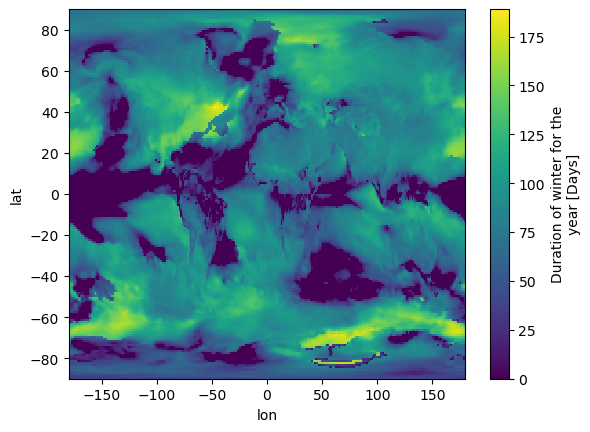

In [35]:
test.WinterLength.plot()

## CESM2 data

#### Load baseline 25% percentile values from CESM2 historical data per grid cell
- prior use of ERA5 baseline showed bias especially for CanESM data

In [49]:
# get baseline
file_path = '../../../../Data/CMIP6/CESM2/FixedCoords/baseline/computed_1961-1990-full_25th.nc'
c_25_cesm = xr.open_dataarray(file_path)
c_25_cesm.values


array([[234.80058289, 234.80616379, 234.80616379, ..., 234.75330353,
        234.75772476, 234.7748642 ],
       [234.26151276, 234.29961014, 234.3295517 , ..., 234.14857483,
        234.18935394, 234.22166824],
       [235.34697723, 235.40986633, 235.47353745, ..., 235.29081345,
        235.28463364, 235.32973862],
       ...,
       [270.73863983, 270.7377243 , 270.72985077, ..., 270.75177765,
        270.74143219, 270.73791504],
       [270.77828217, 270.77237701, 270.78060913, ..., 270.78917694,
        270.78504181, 270.78116608],
       [270.84149933, 270.84282684, 270.84532928, ..., 270.84636688,
        270.84644318, 270.84247589]], shape=(192, 288))

In [50]:
file_path = '../../../../Data/CMIP6/CESM2/FixedCoords/*.nc'
#file_path = '../../../Data/CMIP6/GFDL-ESM4/tas_day_GFDL-ESM4_ssp245_r1i1p1f1_gr1_20150101-20241231.nc'

ds_cesm2 = xr.open_mfdataset(file_path)

In [51]:
ds_cesm2

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 12776, bnds: 2, lon: 288, lat: 192)
Coordinates:
  * time       (time) object 102kB 1990-01-01 00:00:00 ... 2024-12-31 00:00:00
  * lon        (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 204kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 59MB dask.array<chunksize=(3650, 288, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 39MB dask.array<chunksize=(3650, 192, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 3GB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes: (12/44)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.7 CMIP-6.2
    source:                 CESM2 (2017): atmosphere: CAM6 (0.9x1.25 finite v...
    institution:            National Center for Atmospheric Research, Climate...
    activity_id:            CMIP
    case_id:                15
    ...                     ...
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...
    history:                Thu May 14 15:35:29 2026: cdo -sellonlatbox,-180,...
    CDO:                    Climate Data Operators version 2.5.0 (https://mpi...

#### update time variable

In [52]:
ds_cesm2['time'] = ds_cesm2.indexes['time'].to_datetimeindex()
ds_cesm2

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 12776, bnds: 2, lon: 288, lat: 192)
Coordinates:
  * time       (time) datetime64[ns] 102kB 1990-01-01 1990-01-02 ... 2024-12-31
  * lon        (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 204kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 59MB dask.array<chunksize=(3650, 288, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 39MB dask.array<chunksize=(3650, 192, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 3GB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes: (12/44)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.7 CMIP-6.2
    source:                 CESM2 (2017): atmosphere: CAM6 (0.9x1.25 finite v...
    institution:            National Center for Atmospheric Research, Climate...
    activity_id:            CMIP
    case_id:                15
    ...                     ...
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...
    history:                Thu May 14 15:35:29 2026: cdo -sellonlatbox,-180,...
    CDO:                    Climate Data Operators version 2.5.0 (https://mpi...

### Test for Vancouver 2000 - nearest grid cell

In [53]:
#test for Vancouver
input_lat = 49.246
input_lon = -123.116

thresh = c_25_cesm.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh

<xarray.DataArray 'tas' ()> Size: 8B
array(286.113365)
Coordinates:
    lat       float64 8B 49.48
    lon       float64 8B -122.5
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

In [54]:
input_year = 2000

ds = ds_cesm2.sel(time = str(input_year))
curr = ds.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
dsnext = ds_cesm2.sel(time = str(input_year+1))
nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
curr, nxt

(<xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2000-01-01 2000-01-02 ... 2000-12-31
     lon      float64 8B -122.5
     lat      float64 8B 49.48
 Attributes: (12/19)
     standard_name:  air_temperature
     long_name:      Near-Surface Air Temperature
     units:          K
     cell_measures:  area: areacella
     cell_methods:   area: time: mean
     comment:        near-surface (usually, 2 meter) air temperature
     ...             ...
     time:           time
     time_label:     time-mean
     time_title:     Temporal mean
     title:          Near-Surface Air Temperature
     type:           real
     variable_id:    tas,
 <xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2001-01-01 2001-01-0

## CanESM5 data

#### Load baseline 25% percentile values from CanESM5 historical data per grid cell
- prior use of ERA5 baseline showed bias especially for CanESM data

In [25]:
# get baseline
file_path = '../../../../Data/CMIP6/CanESM5/FixedCoords/baseline/computed_1961-1990-full_25th.nc'
c_25_canesm = xr.open_dataarray(file_path)
c_25_canesm.values


array([[241.00008774, 241.21955109, 241.41810226, ..., 240.23161697,
        240.49313354, 240.73985672],
       [253.62111282, 254.04934311, 254.46363449, ..., 252.03792953,
        252.61951065, 253.14171219],
       [259.2420578 , 259.37942505, 259.56554413, ..., 259.14061737,
        259.20709991, 259.18371582],
       ...,
       [269.58872223, 269.48653412, 269.49753571, ..., 269.65457916,
        269.64626312, 269.58562469],
       [268.96660614, 268.94041443, 268.94393921, ..., 269.0973587 ,
        269.05638885, 268.99520111],
       [268.73603058, 268.69161224, 268.69973755, ..., 268.81445312,
        268.789505  , 268.75492859]], shape=(64, 128))

In [26]:
file_path = '../../../../Data/CMIP6/CanESM5/FixedCoords/*.nc'
#file_path = '../../../Data/CMIP6/GFDL-ESM4/tas_day_GFDL-ESM4_ssp245_r1i1p1f1_gr1_20150101-20241231.nc'

ds_canesm5 = xr.open_mfdataset(file_path)

In [27]:
ds_canesm5

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 40515, bnds: 2, lon: 128, lat: 64)
Coordinates:
  * time       (time) object 324kB 1990-01-01 12:00:00 ... 2100-12-31 12:00:00
  * lon        (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 648kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 83MB dask.array<chunksize=(3650, 128, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 41MB dask.array<chunksize=(3650, 64, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 1GB dask.array<chunksize=(1, 64, 128), meta=np.ndarray>
Attributes: (12/55)
    CDI:                         Climate Data Interface version 2.5.0 (https:...
    Conventions:                 CF-1.7 CMIP-6.2
    source:                      CanESM5 (2019): \naerosol: interactive\natmo...
    institution:                 Canadian Centre for Climate Modelling and An...
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    ...                          ...
    variable_id:                 tas
    variant_label:               r1i1p1f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0
    CDO:                         Climate Data Operators version 2.5.0 (https:...

In [6]:
#ds_canesm5.tas.values

#### update time variable

In [28]:
ds_canesm5['time'] = ds_canesm5.indexes['time'].to_datetimeindex()
ds_canesm5

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 40515, bnds: 2, lon: 128, lat: 64)
Coordinates:
  * time       (time) datetime64[ns] 324kB 1990-01-01T12:00:00 ... 2100-12-31...
  * lon        (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 648kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 83MB dask.array<chunksize=(3650, 128, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 41MB dask.array<chunksize=(3650, 64, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 1GB dask.array<chunksize=(1, 64, 128), meta=np.ndarray>
Attributes: (12/55)
    CDI:                         Climate Data Interface version 2.5.0 (https:...
    Conventions:                 CF-1.7 CMIP-6.2
    source:                      CanESM5 (2019): \naerosol: interactive\natmo...
    institution:                 Canadian Centre for Climate Modelling and An...
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    ...                          ...
    variable_id:                 tas
    variant_label:               r1i1p1f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0
    CDO:                         Climate Data Operators version 2.5.0 (https:...

### Test for Vancouver 2000 - nearest grid cell

In [29]:
#test for Vancouver
input_lat = 49.246
input_lon = -123.116

thresh = c_25_canesm.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh

<xarray.DataArray 'tas' ()> Size: 8B
array(285.922417)
Coordinates:
    lon       float64 8B -123.8
    lat       float64 8B 48.84
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

In [30]:
input_year = 2000

ds = ds_canesm5.sel(time = str(input_year))
curr = ds.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
dsnext = ds_canesm5.sel(time = str(input_year+1))
nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
curr, nxt

(<xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2000-01-01T12:00:00 ... 2000-12-31T12:...
     lon      float64 8B -123.8
     lat      float64 8B 48.84
     height   float64 8B 2.0
 Attributes:
     standard_name:     air_temperature
     long_name:         Near-Surface Air Temperature
     units:             K
     CDI_grid_type:     gaussian
     CDI_grid_num_LPE:  32
     comment:           near-surface (usually, 2 meter) air temperature
     original_name:     ST
     cell_methods:      area: time: mean
     cell_measures:     area: areacella
     history:           2019-05-02T08:02:00Z altered by CMOR: Treated scalar d...,
 <xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2001-01-01T12:00:00 ... 2

### Sydney 2070 using ssp2-4.5 data

### Going to go all the way to 2099

In [37]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1990, 2100,1)

process_yrs

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033,
       2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
       2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055,
       2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066,
       2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077,
       2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088,
       2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099])